In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import prep_data, timeseries_train_test_split
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-15 10:18:04,687	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
!pwd

/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/rat_train_on_discrete


In [49]:
algorithm = 'BunDLeNet'
rat_name = 'achilles' # ['achilles', 'gatsby','cicero', 'buddy']
data = np.load(f'../data/raw/rat_hippocampus/{rat_name}.npz')
x, b = data['x'], data['b']
x = x - np.min(x)
b = b[:,1]

In [50]:

x_, b_ = prep_data(x, b, win=50)

# Train test split
x_train, x_test, b_train_1, b_test_1 = timeseries_train_test_split(x_, b_)

# Deploy BunDLe Net
model = BunDLeNet(latent_dim=3, num_behaviour=len(np.unique(b)), input_shape=x_.shape)

train_history, test_history = train_model(
    x_train,
    b_train_1,
    model,
    b_type='discrete',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=50,
    #initialisation=(5,20),
    validation_data=(x_test, b_test_1),
)


Loss [Markov, Behaviour, Total]: [0.0054 0.0011 0.0065]: 100%|█| 50/50 [00:27<00:00, 


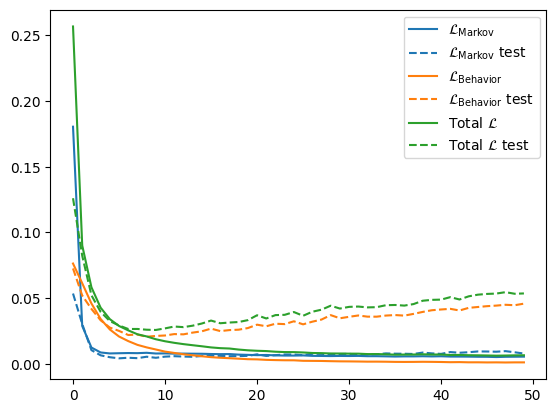

In [51]:
plt.figure()
colors =  ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total $\mathcal{L}$"
]):
    plt.plot(train_history[:, i], label=label, c=colors[i])
    plt.plot(test_history[:, i], label=label + ' test', c=colors[i], linestyle='--')
plt.legend()

In [52]:
# projecting into latent space
y0_tr = project_into_latent_space(x_train[:, 0], model)
y1_tr = project_into_latent_space(x_train[:, 1], model)
y0_tst = project_into_latent_space(x_test[:, 0], model)
y1_tst = project_into_latent_space(x_test[:, 1], model)
y0_ = project_into_latent_space(x_[:, 0 ], model)
y1_ = project_into_latent_space(x_[:, 1 ], model)

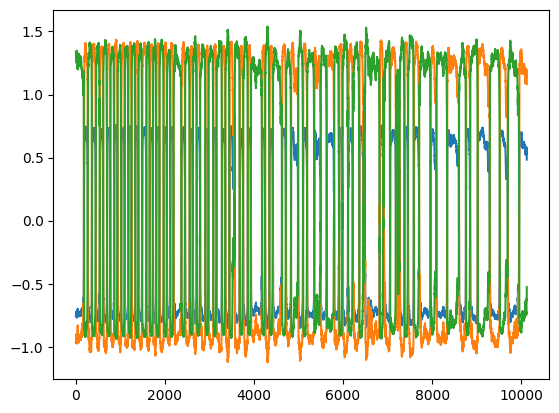

In [53]:
plt.figure()
plt.plot(y0_)

<IPython.core.display.Javascript object>


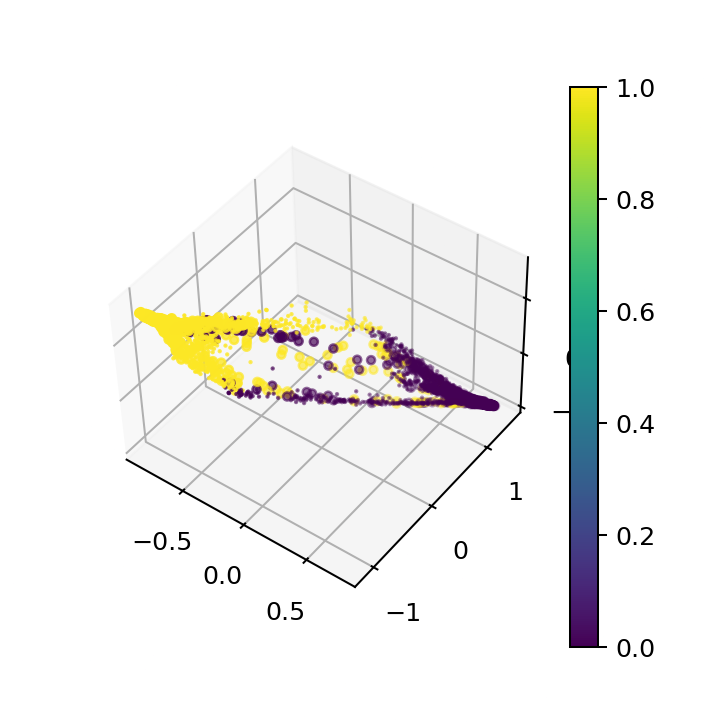

In [54]:
%matplotlib notebook
# Continuous variable plotting
fig = plt.figure(figsize=(4, 4))
ax = plt.axes(projection='3d')
# ax.axis('off')
tr_pts = ax.scatter(y0_tr[:, 0], y0_tr[:, 1], y0_tr[:, 2], c=b_train_1, s=0.5)
tst_pts = ax.scatter(y0_tst[:, 0], y0_tst[:, 1], y0_tst[:, 2], c=b_test_1, s=10)
plt.colorbar(tr_pts)
plt.show()

<IPython.core.display.Javascript object>


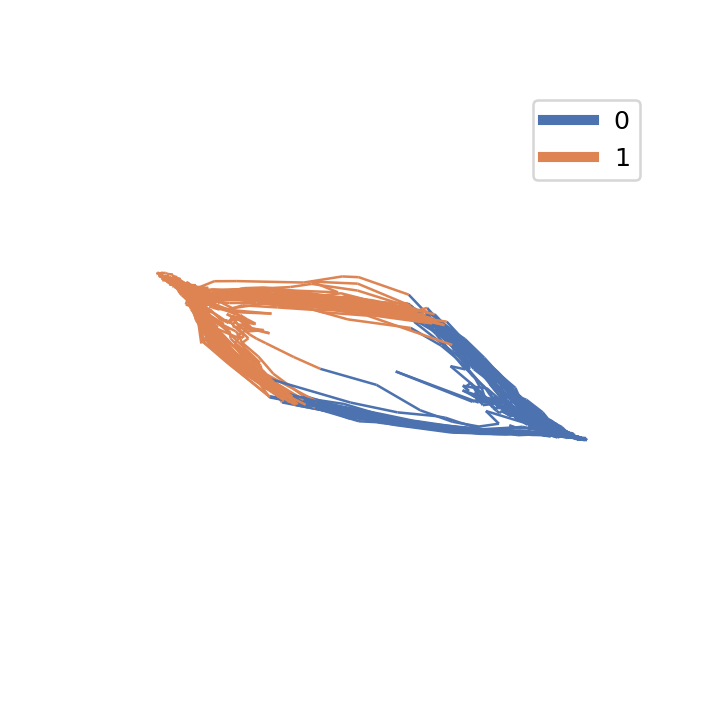

In [55]:
# Discrete variable plotting
fig = plt.figure(figsize=(4, 4))
ax = plt.axes(projection='3d')

vis = LatentSpaceVisualiser(
    y=y0_tr,
    b=b_train_1.astype(int),
    b_names=['0', '1']
)
fig, ax = vis._plot_ps(fig, ax, arrow_length_ratio=0.0001)
'''
vis = LatentSpaceVisualiser(
    y=y0_tst,
    b=b_test_1.astype(int),
    b_names=['0', '1'],
    show_points=True
)
fig, ax = vis._plot_ps(fig, ax, arrow_length_ratio=0.01)
'''
plt.show()

In [56]:
rat_name = 'achilles' # ['achilles', 'gatsby','cicero', 'buddy']
data = np.load(f'../data/raw/rat_hippocampus/{rat_name}.npz')
x, b = data['x'], data['b']
x = x - np.min(x)
b = b[:,0]

x_, b_ = prep_data(x, b, win=50)

# Train test split
_, _, b_train, b_test = timeseries_train_test_split(x_, b_)


In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fit linear regressor
reg = LinearRegression()
reg.fit(y0_tr, b_train)

# Predict
b_pred = reg.predict(y0_tst)

# Evaluate
mse = mean_squared_error(b_test, b_pred)
r2_model = r2_score(b_test, b_pred)

print(f"MSE: {mse:.4f}")
print(f"R² score: {r2_model:.4f}")


MSE: 0.1398
R² score: 0.4245


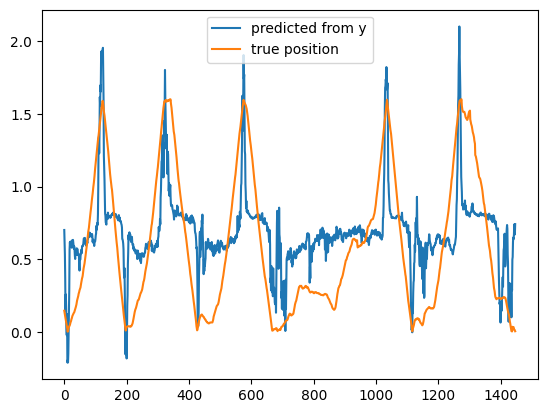

In [59]:
%matplotlib inline
plt.figure()
plt.plot(b_pred, label='predicted from y')
plt.plot(b_test, label='true position')
plt.legend()

In [62]:
import numpy as np

# Number of permutations
n_permutations = 1000
r2_permuted = []

# Run permutation test
for _ in range(n_permutations):
    b_test_shuffled = np.random.permutation(b_test)
    r2_permuted.append(r2_score(b_test, b_test_shuffled))

# Compute p-value (one-sided test: how often chance R² ≥ observed R²)
p_value = np.mean(np.array(r2_permuted) >= r2_model)

print(f"Observed R²: {r2_model:.4f}")
print(f"Permutation p-value: {p_value:.4f}")


Observed R²: 0.4245
Permutation p-value: 0.0000


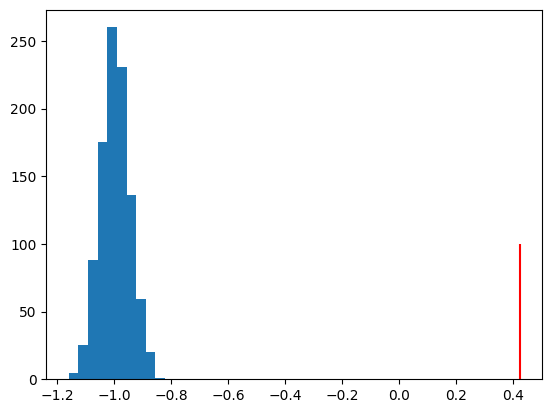

In [63]:
plt.figure()
plt.hist(r2_permuted)
plt.vlines(x=r2_model, ymax=100, ymin=0, color = 'r')
plt.show()